Saving titanic.csv to titanic.csv
First 5 Rows
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Columns in Dataset:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'al

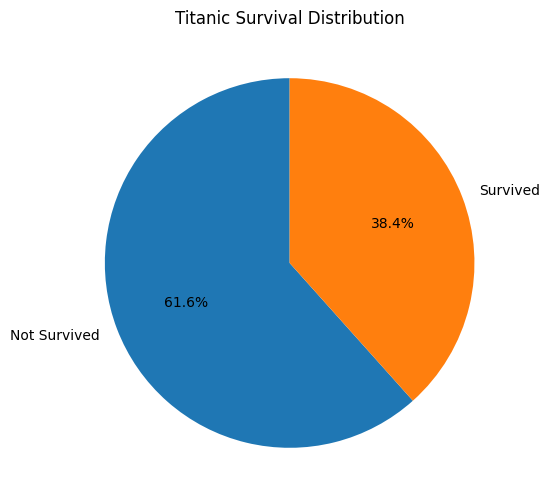

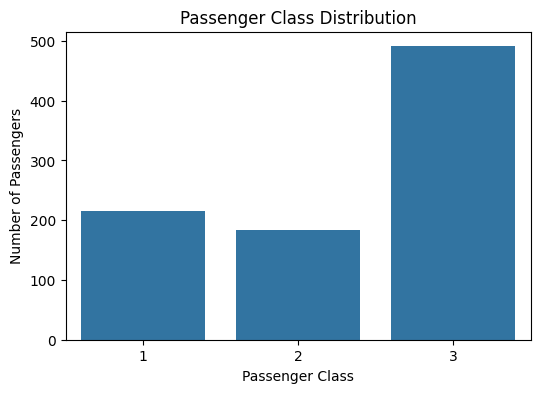


Accuracy Score
78.21 %

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       105
           1       0.75      0.72      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179


Sample Prediction
     pclass  sex        age     fare  embarked
709       3    1  29.699118  15.2458         0

Prediction : Not Survived


In [ ]:
# Install libraries (Run only once)
!pip install pandas matplotlib seaborn scikit-learn

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ===============================
# Upload Dataset
# ===============================
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read Dataset
df = pd.read_csv(filename)

# Display First 5 Rows
print("First 5 Rows")
print(df.head())

print("\nColumns in Dataset:")
print(df.columns)

# ===============================
# Convert Column Names to Lowercase
# ===============================
df.columns = df.columns.str.lower()

# ===============================
# Select Required Columns
# ===============================
data = df[['pclass','sex','age','fare','embarked','survived']].copy()

# ===============================
# Handle Missing Values
# ===============================
num = SimpleImputer(strategy='mean')
cat = SimpleImputer(strategy='most_frequent')

data['age'] = num.fit_transform(data[['age']])
data['fare'] = num.fit_transform(data[['fare']])

data['sex'] = cat.fit_transform(data[['sex']]).ravel()
data['embarked'] = cat.fit_transform(data[['embarked']]).ravel()

# ===============================
# Encode Text Columns
# ===============================
le = LabelEncoder()

data['sex'] = le.fit_transform(data['sex'])
data['embarked'] = le.fit_transform(data['embarked'])

# ===============================
# PIE CHART
# ===============================
plt.figure(figsize=(6,6))

data['survived'].value_counts().plot(
    kind='pie',
    labels=['Not Survived','Survived'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Titanic Survival Distribution")
plt.ylabel("")
plt.show()

# ===============================
# BAR CHART
# ===============================
plt.figure(figsize=(6,4))

sns.countplot(x='pclass', data=data)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

# ===============================
# Machine Learning
# ===============================
X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ===============================
# Accuracy
# ===============================
print("\nAccuracy Score")
print(round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ===============================
# Sample Prediction
# ===============================
print("\nSample Prediction")

sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print(sample)

if prediction[0] == 1:
    print("\nPrediction : Survived")
else:
    print("\nPrediction : Not Survived")